# BiLSTM + Degradation Mechanism Regularization

**Complete pipeline — self-contained, run from scratch.**

## Architecture
- **Branch A:** BiLSTM (2-layer bidirectional) over 51-frequency EIS spectrum
- **Branch B:** Dense MLP over 9 ECM parameters (optional — part of 2×2 factorial)
- **Fusion:** Separate SoC and SoH paths (unchanged from Run C)
- **Heads:** SoC (2), SoH (2), **Degradation (3)** — CL%, LLI%, LAM%
- **Uncertainty:** MC Dropout (T=50), epistemic/aleatoric decomposition

## 2×2 Factorial design
| Config | ECM input | Deg loss | What it tests |
|---|---|---|---|
| C1: BiLSTM-only | No | No | Pure data-driven baseline |
| C2: BiLSTM + ECM | Yes | No | Physics as input |
| C3: BiLSTM + Deg | No | Yes | Physics as constraint |
| C4: BiLSTM + ECM + Deg | Yes | Yes | Both pathways |

## Training protocol (matched across all configs)
- lr=1e-3, λ_soh=0.3, warmup=20, patience=40, max_epochs=400
- LOCO 8-fold, StandardScaler on train only, seed=42

**Runtime: ~50 min on CPU (4 configs × 8 folds × ~1.5 min/fold)**

**Before running:** Place `leonardi_final.npz` in the same folder.

## 1. Imports & reproducibility

In [1]:
import os, random, copy, time, warnings, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

g = torch.Generator(); g.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}, Seed: {SEED}")

Device: cpu, Seed: 42


## 2. Load data + compute degradation labels (CL%, LLI%, LAM%)

In [2]:
data = np.load('leonardi_final.npz', allow_pickle=True)
X_seq_np      = data['X_seq'].astype(np.float32)       # (488, 51, 3)
X_tab_np      = data['X_tab'].astype(np.float32)       # (488, 9)
y_SoC_norm_np = data['y_SoC_norm'].astype(np.float32)  # (488,)
y_SoH_norm_np = data['y_SoH_norm'].astype(np.float32)  # (488,)
cell_ids      = data['cell_ids']
protocols     = data['protocols']
cycles        = data['cycles']

# ─── Compute CL%, LLI%, LAM% from ECM parameters ───
# X_tab columns: [L, R_ohm, R_ct1, Q1, alpha1, R_ct2, Q2, alpha2, Z_w]
#                  0    1      2     3     4       5     6     7      8
#
# Equations (Leonardi et al.):
#   CL_k  = (R_ohm_k - R_ohm_0) / R_ohm_0 × 100
#   LLI_k = [(R_ct1_k - R_ct1_0) + (R_ct2_k - R_ct2_0)] / (R_ct1_0 + R_ct2_0) × 100
#   LAM_k = (Z_w_k - Z_w_0) / Z_w_0 × 100

CL_raw  = np.zeros(len(X_tab_np), dtype=np.float32)
LLI_raw = np.zeros(len(X_tab_np), dtype=np.float32)
LAM_raw = np.zeros(len(X_tab_np), dtype=np.float32)

for cell_id in np.unique(cell_ids):
    mask = (cell_ids == cell_id)
    cycs = cycles[mask]
    cycle_0_mask = mask & (cycles == cycs.min())

    # Cycle-0 reference = mean over SoC levels at earliest cycle
    R_ohm_0 = X_tab_np[cycle_0_mask, 1].mean()
    R_ct1_0 = X_tab_np[cycle_0_mask, 2].mean()
    R_ct2_0 = X_tab_np[cycle_0_mask, 5].mean()
    Z_w_0   = X_tab_np[cycle_0_mask, 8].mean()

    R_ohm_k = X_tab_np[mask, 1]
    R_ct1_k = X_tab_np[mask, 2]
    R_ct2_k = X_tab_np[mask, 5]
    Z_w_k   = X_tab_np[mask, 8]

    CL_raw[mask]  = (R_ohm_k - R_ohm_0) / (R_ohm_0 + 1e-10) * 100
    LLI_raw[mask] = ((R_ct1_k - R_ct1_0) + (R_ct2_k - R_ct2_0)) / \
                    (R_ct1_0 + R_ct2_0 + 1e-10) * 100
    LAM_raw[mask] = (Z_w_k - Z_w_0) / (Z_w_0 + 1e-10) * 100

# ─── Clip to physically reasonable bounds ───
CL_raw  = np.clip(CL_raw,  -10,  50)
LLI_raw = np.clip(LLI_raw, -10, 100)
LAM_raw = np.clip(LAM_raw, -10, 100)    

# Normalize to [0, 1] for training (per-target min-max)
# Store scalers for denormalization at eval time
deg_stats = {}
y_deg_np = np.stack([CL_raw, LLI_raw, LAM_raw], axis=1)  # (488, 3)
y_deg_norm_np = np.zeros_like(y_deg_np)
for i, name in enumerate(['CL', 'LLI', 'LAM']):
    lo, hi = y_deg_np[:, i].min(), y_deg_np[:, i].max()
    rng = hi - lo if hi != lo else 1.0
    y_deg_norm_np[:, i] = (y_deg_np[:, i] - lo) / rng
    deg_stats[name] = {'min': lo, 'max': hi, 'range': rng}

print(f"Dataset: {len(y_SoC_norm_np)} samples")
print(f"\nDegradation label ranges (raw %):")
for name in ['CL', 'LLI', 'LAM']:
    s = deg_stats[name]
    print(f"  {name:>3}: [{s['min']:>8.2f}%, {s['max']:>8.2f}%]")
print(f"\nDeg labels shape: {y_deg_np.shape}")
print(f"Normalized to [0,1] for training")

Dataset: 488 samples

Degradation label ranges (raw %):
   CL: [   -1.29%,    14.46%]
  LLI: [  -10.00%,   100.00%]
  LAM: [  -10.00%,   100.00%]

Deg labels shape: (488, 3)
Normalized to [0,1] for training


## 3. Dataset class (with optional degradation targets)

In [3]:
class EISDataset(Dataset):
    """Returns (X_seq, X_tab, y_SoC, y_SoH, y_deg)."""
    def __init__(self, X_seq, X_tab, y_SoC, y_SoH, y_deg=None):
        self.X_seq = X_seq; self.X_tab = X_tab
        self.y_SoC = y_SoC; self.y_SoH = y_SoH
        self.y_deg = y_deg if y_deg is not None else torch.zeros(len(y_SoC), 3)
    def __len__(self): return len(self.y_SoC)
    def __getitem__(self, i):
        return (self.X_seq[i], self.X_tab[i],
                self.y_SoC[i], self.y_SoH[i], self.y_deg[i])

print("EISDataset defined (5-tuple output)")

EISDataset defined (5-tuple output)


## 4. Architecture — BiLSTM branches + degradation head

Four model classes for the 2×2 factorial.

In [4]:
class LSTMBranch(nn.Module):
    """Bidirectional LSTM over 51-frequency EIS spectrum."""
    def __init__(self, in_channels=3, d_model=64,
                 hidden_size=96, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.lstm = nn.LSTM(
            input_size=d_model, hidden_size=hidden_size,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=True)
        self.output_proj = nn.Linear(hidden_size * 2, d_model)
        self.dropout = nn.Dropout(p=dropout)
    def forward(self, x):
        x = self.input_proj(x)
        x, _ = self.lstm(x)
        x = x.mean(dim=1)
        x = self.output_proj(x)
        x = self.dropout(x)
        return x


class MLPBranch(nn.Module):
    """Dense MLP over 9 ECM parameters."""
    def __init__(self, in_features=9, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(p=dropout))
    def forward(self, x): return self.net(x)


class BiLSTM_Config(nn.Module):
    """
    Configurable BiLSTM model for the 2×2 factorial.

    Args:
        use_ecm:  if True, includes MLPBranch (ECM input)
        use_deg:  if True, includes degradation auxiliary head (CL, LLI, LAM)
    """
    def __init__(self, d_model=64, hidden_size=96, n_layers=2,
                 dropout=0.1, use_ecm=False, use_deg=False):
        super().__init__()
        self.use_ecm = use_ecm
        self.use_deg = use_deg

        self.branch_a = LSTMBranch(3, d_model, hidden_size, n_layers, dropout)

        if use_ecm:
            self.branch_b = MLPBranch(9, d_model, dropout)
            fusion_in = d_model * 2
        else:
            self.branch_b = None
            fusion_in = d_model

        # SoC fusion (deeper)
        self.fusion_SoC = nn.Sequential(
            nn.Linear(fusion_in, d_model),
            nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(p=dropout),
            nn.Linear(d_model, d_model // 2),
            nn.LayerNorm(d_model // 2), nn.GELU(), nn.Dropout(p=dropout))

        # SoH fusion (shallower)
        self.fusion_SoH = nn.Sequential(
            nn.Linear(fusion_in, d_model),
            nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(p=dropout))

        # Main heads
        self.head_SoC = nn.Linear(d_model // 2, 2)  # mu, log_sigma
        self.head_SoH = nn.Linear(d_model, 2)

        # Degradation auxiliary head (lightweight — single linear layer)
        if use_deg:
            self.head_deg = nn.Linear(fusion_in, 3)  # CL, LLI, LAM
        else:
            self.head_deg = None

        # Bias init
        with torch.no_grad():
            self.head_SoC.bias[1] = -3.0
            self.head_SoH.bias[1] = -3.0

    def forward(self, x_seq, x_tab=None):
        h_a = self.branch_a(x_seq)

        if self.use_ecm and x_tab is not None:
            h_b = self.branch_b(x_tab)
            h = torch.cat([h_a, h_b], dim=-1)
        else:
            h = h_a

        # SoC/SoH outputs
        out_SoC = self.head_SoC(self.fusion_SoC(h))
        out_SoH = self.head_SoH(self.fusion_SoH(h))
        mu_SoC = torch.sigmoid(out_SoC[:, 0])
        ls_SoC = out_SoC[:, 1]
        mu_SoH = torch.sigmoid(out_SoH[:, 0]) * 0.23 + 0.77
        ls_SoH = out_SoH[:, 1]

        # Degradation output (if enabled)
        if self.head_deg is not None:
            deg_pred = torch.sigmoid(self.head_deg(h))  # (B, 3) in [0, 1]
        else:
            deg_pred = None

        return mu_SoC, ls_SoC, mu_SoH, ls_SoH, deg_pred


# ─── Param count for each config ───
configs = {
    'C1: BiLSTM-only':         {'use_ecm': False, 'use_deg': False},
    'C2: BiLSTM + ECM':        {'use_ecm': True,  'use_deg': False},
    'C3: BiLSTM + Deg':        {'use_ecm': False, 'use_deg': True},
    'C4: BiLSTM + ECM + Deg':  {'use_ecm': True,  'use_deg': True},
}
print("Parameter counts:")
for name, kwargs in configs.items():
    m = BiLSTM_Config(**kwargs)
    n = sum(p.numel() for p in m.parameters())
    print(f"  {name:<25} : {n:>8,} params")

Parameter counts:
  C1: BiLSTM-only           :  370,660 params
  C2: BiLSTM + ECM          :  383,908 params
  C3: BiLSTM + Deg          :  370,855 params
  C4: BiLSTM + ECM + Deg    :  384,295 params


## 5. Loss function with optional degradation term

In [5]:
def nll_loss(mu, log_sigma, y):
    ls = torch.clamp(log_sigma, min=-5.0, max=2.0)
    sigma2_inv = torch.exp(-2.0 * ls)
    return (ls + 0.5 * sigma2_inv * (y - mu) ** 2).mean()


def total_loss(mu_soc, ls_soc, mu_soh, ls_soh, y_soc, y_soh,
               deg_pred=None, y_deg=None,
               lam=0.3,
               sigma_penalty_soc=0.10,
               sigma_penalty_soh=0.05,
               mae_weight=0.5,
               lam_deg=0.5):
    """
    Combined loss:
      L = NLL_SoC + λ·NLL_SoH
        + mae_weight·(MAE_SoC + λ·MAE_SoH)
        + σ_penalty
        + λ_deg·MSE(deg_pred, y_deg)     ← NEW (only if deg_pred is not None)
    """
    ls_soc = torch.clamp(ls_soc, min=-6.0, max=2.0)
    ls_soh = torch.clamp(ls_soh, min=-6.0, max=2.0)

    l_soc = nll_loss(mu_soc, ls_soc, y_soc)
    l_soh = nll_loss(mu_soh, ls_soh, y_soh)
    mae_soc = torch.abs(mu_soc - y_soc).mean()
    mae_soh = torch.abs(mu_soh - y_soh).mean()
    penalty = (sigma_penalty_soc * ls_soc.mean()
               + sigma_penalty_soh * ls_soh.mean())

    total = (l_soc + lam * l_soh
             + mae_weight * (mae_soc + lam * mae_soh)
             + penalty)

    # Degradation auxiliary loss
    l_deg = 0.0
    if deg_pred is not None and y_deg is not None:
        l_deg = nn.functional.mse_loss(deg_pred, y_deg)
        total = total + lam_deg * l_deg

    return total, l_soc.item(), l_soh.item(), float(l_deg)

print("Loss function defined (with optional degradation term)")

Loss function defined (with optional degradation term)


## 6. MC Dropout inference + metrics

In [6]:
def mc_predict(model, x_seq, x_tab, T=50):
    model.train()
    mus_soc, mus_soh, vars_soc, vars_soh = [], [], [], []
    deg_preds = []
    with torch.no_grad():
        for _ in range(T):
            mu_s, ls_s, mu_h, ls_h, deg = model(x_seq, x_tab)
            ls_s = torch.clamp(ls_s, -6.0, 2.0)
            ls_h = torch.clamp(ls_h, -6.0, 2.0)
            mus_soc.append(mu_s); mus_soh.append(mu_h)
            vars_soc.append(torch.exp(2.0 * ls_s))
            vars_soh.append(torch.exp(2.0 * ls_h))
            if deg is not None:
                deg_preds.append(deg)
    mus_soc = torch.stack(mus_soc); mus_soh = torch.stack(mus_soh)
    vars_soc = torch.stack(vars_soc); vars_soh = torch.stack(vars_soh)
    epi_soc = mus_soc.var(dim=0); epi_soh = mus_soh.var(dim=0)
    alea_soc = vars_soc.mean(dim=0); alea_soh = vars_soh.mean(dim=0)
    result = {
        'mu_SoC': mus_soc.mean(dim=0), 'mu_SoH': mus_soh.mean(dim=0),
        'sigma_epi_SoC': epi_soc.sqrt(), 'sigma_epi_SoH': epi_soh.sqrt(),
        'sigma_alea_SoC': alea_soc.sqrt(), 'sigma_alea_SoH': alea_soh.sqrt(),
        'sigma_total_SoC': (epi_soc + alea_soc).sqrt(),
        'sigma_total_SoH': (epi_soh + alea_soh).sqrt(),
    }
    if deg_preds:
        result['deg_pred'] = torch.stack(deg_preds).mean(dim=0)  # (B, 3)
    return result


def picp(mu, sigma, y, z=1.645):
    return np.mean((y >= mu - z * sigma) & (y <= mu + z * sigma))


def evaluate_fold(model, cell_id, sc_seq, sc_tab, use_ecm, T=50):
    mask = (cell_ids == cell_id)
    Xs = sc_seq.transform(X_seq_np[mask].reshape(-1, 3))\
               .reshape(-1, 51, 3).astype(np.float32)
    Xt = sc_tab.transform(X_tab_np[mask]).astype(np.float32)
    x_seq_t = torch.tensor(Xs).to(device)
    x_tab_t = torch.tensor(Xt).to(device) if use_ecm else None
    preds = mc_predict(model, x_seq_t, x_tab_t, T=T)
    preds_np = {k: v.cpu().numpy() for k, v in preds.items()}
    z = 1.645
    mu_soc = preds_np['mu_SoC'] * 100; y_soc = y_SoC_norm_np[mask] * 100
    mu_soh = preds_np['mu_SoH'] * 100; y_soh = y_SoH_norm_np[mask] * 100
    sig_soc = preds_np['sigma_total_SoC'] * 100
    sig_soh = preds_np['sigma_total_SoH'] * 100
    result = {
        'SoC': {
            'MAE': np.mean(np.abs(mu_soc - y_soc)),
            'RMSE': np.sqrt(np.mean((mu_soc - y_soc)**2)),
            'PICP': picp(mu_soc, sig_soc, y_soc),
            'sigma_epi': np.mean(preds_np['sigma_epi_SoC']) * 100,
            'sigma_alea': np.mean(preds_np['sigma_alea_SoC']) * 100,
        },
        'SoH': {
            'MAE': np.mean(np.abs(mu_soh - y_soh)),
            'RMSE': np.sqrt(np.mean((mu_soh - y_soh)**2)),
            'PICP': picp(mu_soh, sig_soh, y_soh),
            'sigma_epi': np.mean(preds_np['sigma_epi_SoH']) * 100,
            'sigma_alea': np.mean(preds_np['sigma_alea_SoH']) * 100,
        },
    }
    # Degradation accuracy (if head exists)
    if 'deg_pred' in preds_np:
        deg_true = y_deg_np[mask]  # raw % values
        deg_pred_norm = preds_np['deg_pred']  # in [0,1]
        # Denormalize
        deg_pred_raw = np.zeros_like(deg_pred_norm)
        for i, name in enumerate(['CL', 'LLI', 'LAM']):
            s = deg_stats[name]
            deg_pred_raw[:, i] = deg_pred_norm[:, i] * s['range'] + s['min']
        result['Deg'] = {}
        for i, name in enumerate(['CL', 'LLI', 'LAM']):
            result['Deg'][name] = {
                'MAE': np.mean(np.abs(deg_pred_raw[:, i] - deg_true[:, i])),
            }
    return result

print("MC Dropout + evaluation functions defined")

MC Dropout + evaluation functions defined


## 7. LOCO split, scaler, training

In [7]:
def loco_split(cell_ids, test_cell):
    test_mask = (cell_ids == test_cell)
    return ~test_mask, test_mask

def scale_and_build(X_seq, X_tab, y_SoC, y_SoH, y_deg_norm,
                    train_mask, test_mask, batch_size=32):
    sc_seq = StandardScaler()
    sc_seq.fit(X_seq[train_mask].reshape(-1, 3))
    def tx(X):
        n = X.shape[0]
        return sc_seq.transform(X.reshape(-1, 3))\
                     .reshape(n, 51, 3).astype(np.float32)
    Xs_tr = tx(X_seq[train_mask]); Xs_te = tx(X_seq[test_mask])
    sc_tab = StandardScaler(); sc_tab.fit(X_tab[train_mask])
    Xt_tr = sc_tab.transform(X_tab[train_mask]).astype(np.float32)
    Xt_te = sc_tab.transform(X_tab[test_mask]).astype(np.float32)
    ds_tr = EISDataset(
        torch.tensor(Xs_tr), torch.tensor(Xt_tr),
        torch.tensor(y_SoC[train_mask]), torch.tensor(y_SoH[train_mask]),
        torch.tensor(y_deg_norm[train_mask]))
    ds_te = EISDataset(
        torch.tensor(Xs_te), torch.tensor(Xt_te),
        torch.tensor(y_SoC[test_mask]), torch.tensor(y_SoH[test_mask]),
        torch.tensor(y_deg_norm[test_mask]))
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,
                       worker_init_fn=seed_worker, generator=g)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False,
                       worker_init_fn=seed_worker, generator=g)
    return dl_tr, dl_te, sc_seq, sc_tab


class EarlyStopping:
    def __init__(self, patience=40, min_delta=1e-4):
        self.patience = patience; self.min_delta = min_delta
        self.best_loss = np.inf; self.counter = 0; self.best_state = None
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss; self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience
    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, optimizer, lam, device,
              train=True, use_ecm=False, use_deg=False):
    model.train() if train else model.eval()
    ctx = torch.enable_grad() if train else torch.no_grad()
    tot, n = 0., 0
    with ctx:
        for x_seq, x_tab, y_soc, y_soh, y_deg in loader:
            x_seq = x_seq.to(device); y_soc = y_soc.to(device)
            y_soh = y_soh.to(device)
            x_tab_in = x_tab.to(device) if use_ecm else None
            y_deg_in = y_deg.to(device) if use_deg else None
            mu_s, ls_s, mu_h, ls_h, deg_pred = model(x_seq, x_tab_in)
            loss, _, _, _ = total_loss(
                mu_s, ls_s, mu_h, ls_h, y_soc, y_soh,
                deg_pred=deg_pred if use_deg else None,
                y_deg=y_deg_in, lam=lam)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
            b = len(y_soc)
            tot += loss.item() * b; n += b
    return tot / n


def train_config(config_name, use_ecm, use_deg,
                 lr=1e-3, lam=0.3, max_epochs=400,
                 patience=25, warmup_epochs=10):
    """Train all 8 LOCO folds for one configuration."""
    print(f"\n{'='*65}")
    print(f"{config_name}")
    print(f"  use_ecm={use_ecm}, use_deg={use_deg}")
    print(f"{'='*65}")

    results = {}
    for cell_id in range(1, 9):
        prot = protocols[cell_ids == cell_id][0]
        n_test = (cell_ids == cell_id).sum()
        print(f"\n  Fold {cell_id}/8 — Cell {cell_id:02d} ({prot}, {n_test} samples)")
        t0 = time.time()

        dl_tr, dl_te, sc_seq, sc_tab = scale_and_build(
            X_seq_np, X_tab_np, y_SoC_norm_np, y_SoH_norm_np,
            y_deg_norm_np,
            *loco_split(cell_ids, cell_id), batch_size=32)

        model = BiLSTM_Config(
            use_ecm=use_ecm, use_deg=use_deg).to(device)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = None
        stopper = EarlyStopping(patience=patience)

        for epoch in range(1, max_epochs + 1):
            if epoch <= warmup_epochs:
                for pg in opt.param_groups:
                    pg['lr'] = lr * (epoch / warmup_epochs)
            if epoch == warmup_epochs + 1 and scheduler is None:
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)

            run_epoch(model, dl_tr, opt, lam, device,
                      train=True, use_ecm=use_ecm, use_deg=use_deg)
            va = run_epoch(model, dl_te, opt, lam, device,
                           train=False, use_ecm=use_ecm, use_deg=use_deg)
            if scheduler is not None: scheduler.step(va)
            if epoch > warmup_epochs:
                if stopper.step(va, model): break
            else:
                if va < stopper.best_loss - stopper.min_delta:
                    stopper.best_loss = va
                    stopper.best_state = copy.deepcopy(model.state_dict())

        stopper.restore(model)
        metrics = evaluate_fold(model, cell_id, sc_seq, sc_tab,
                                use_ecm=use_ecm, T=50)
        results[cell_id] = {**metrics, 'prot': prot}
        elapsed = time.time() - t0
        deg_str = ''
        if 'Deg' in metrics:
            deg_str = (f"  CL={metrics['Deg']['CL']['MAE']:.1f}% "
                       f"LLI={metrics['Deg']['LLI']['MAE']:.1f}% "
                       f"LAM={metrics['Deg']['LAM']['MAE']:.1f}%")
        print(f"    {elapsed:.1f}s → MAE_SoC={metrics['SoC']['MAE']:.2f}%  "
              f"MAE_SoH={metrics['SoH']['MAE']:.2f}%  "
              f"PICP_SoC={metrics['SoC']['PICP']:.3f}"
              f"{deg_str}")
    return results

print("Training pipeline defined")

Training pipeline defined


## 8. Run 2×2 factorial design

**~50 minutes on CPU.** Trains all four configurations.

In [8]:
all_configs = {}

all_configs['C1'] = train_config(
    'C1: BiLSTM-only', use_ecm=False, use_deg=False)

all_configs['C2'] = train_config(
    'C2: BiLSTM + ECM', use_ecm=True, use_deg=False)

all_configs['C3'] = train_config(
    'C3: BiLSTM + Deg loss', use_ecm=False, use_deg=True)

all_configs['C4'] = train_config(
    'C4: BiLSTM + ECM + Deg loss', use_ecm=True, use_deg=True)

print("\n\nAll 4 configurations trained successfully")


C1: BiLSTM-only
  use_ecm=False, use_deg=False

  Fold 1/8 — Cell 01 (AP1, 60 samples)
    111.2s → MAE_SoC=1.49%  MAE_SoH=0.85%  PICP_SoC=0.967

  Fold 2/8 — Cell 02 (AP1, 60 samples)
    235.0s → MAE_SoC=0.21%  MAE_SoH=0.27%  PICP_SoC=1.000

  Fold 3/8 — Cell 03 (AP2, 48 samples)
    169.2s → MAE_SoC=0.26%  MAE_SoH=0.42%  PICP_SoC=1.000

  Fold 4/8 — Cell 04 (AP2, 60 samples)
    208.0s → MAE_SoC=0.22%  MAE_SoH=0.43%  PICP_SoC=1.000

  Fold 5/8 — Cell 05 (AP3, 45 samples)
    41.6s → MAE_SoC=9.35%  MAE_SoH=3.65%  PICP_SoC=0.978

  Fold 6/8 — Cell 06 (AP3, 45 samples)
    102.1s → MAE_SoC=2.58%  MAE_SoH=1.25%  PICP_SoC=0.933

  Fold 7/8 — Cell 07 (AP4, 85 samples)
    81.2s → MAE_SoC=3.99%  MAE_SoH=2.14%  PICP_SoC=0.953

  Fold 8/8 — Cell 08 (AP4, 85 samples)
    179.9s → MAE_SoC=0.92%  MAE_SoH=0.69%  PICP_SoC=0.988

C2: BiLSTM + ECM
  use_ecm=True, use_deg=False

  Fold 1/8 — Cell 01 (AP1, 60 samples)
    64.3s → MAE_SoC=4.07%  MAE_SoH=1.31%  PICP_SoC=1.000

  Fold 2/8 — Cell 02 (AP

## 9. Full comparison table

In [9]:
id_cells, ood_cells = [1, 2, 3, 4], [5, 6, 7, 8]

def agg(results, cells, target, key):
    return np.mean([results[c][target][key] for c in cells])

print("=" * 95)
print("2×2 FACTORIAL — BiLSTM architecture comparison")
print("=" * 95)

print(f"\n{'Config':<25} {'Split':<10} "
      f"{'MAE_SoC':>10} {'PICP_SoC':>10} {'σ_epi_SoC':>12} "
      f"{'MAE_SoH':>10} {'PICP_SoH':>10}")
print("-" * 95)

config_labels = {
    'C1': 'BiLSTM-only',
    'C2': 'BiLSTM + ECM',
    'C3': 'BiLSTM + Deg',
    'C4': 'BiLSTM + ECM + Deg',
}

for key in ['C1', 'C2', 'C3', 'C4']:
    res = all_configs[key]
    for sn, sc in [('In-dist', id_cells), ('OOD', ood_cells),
                    ('Overall', list(range(1, 9)))]:
        print(f"  {config_labels[key]:<23} {sn:<10} "
              f"{agg(res, sc, 'SoC', 'MAE'):>9.2f}% "
              f"{agg(res, sc, 'SoC', 'PICP'):>10.3f} "
              f"{agg(res, sc, 'SoC', 'sigma_epi'):>11.2f}% "
              f"{agg(res, sc, 'SoH', 'MAE'):>9.2f}% "
              f"{agg(res, sc, 'SoH', 'PICP'):>10.3f}")
    print()

# Degradation accuracy (configs C3 and C4)
print("\n" + "=" * 60)
print("DEGRADATION MECHANISM PREDICTION ACCURACY")
print("=" * 60)
for key in ['C3', 'C4']:
    res = all_configs[key]
    print(f"\n  {config_labels[key]}:")
    for deg_name in ['CL', 'LLI', 'LAM']:
        mae_id = np.mean([res[c]['Deg'][deg_name]['MAE'] for c in id_cells])
        mae_ood = np.mean([res[c]['Deg'][deg_name]['MAE'] for c in ood_cells])
        mae_all = np.mean([res[c]['Deg'][deg_name]['MAE'] for c in range(1, 9)])
        print(f"    {deg_name:>3} → In-dist: {mae_id:>6.2f}%  "
              f"OOD: {mae_ood:>6.2f}%  Overall: {mae_all:>6.2f}%")

# Epistemic ratio
print("\n" + "=" * 60)
print("GAP 5 — Epistemic OOD detection")
print("=" * 60)
for key in ['C1', 'C2', 'C3', 'C4']:
    res = all_configs[key]
    id_epi  = np.mean([res[c]['SoC']['sigma_epi'] for c in id_cells])
    ood_epi = np.mean([res[c]['SoC']['sigma_epi'] for c in [5, 6]])
    ratio = ood_epi / id_epi if id_epi > 0 else 0
    print(f"  {config_labels[key]:<23}: σ_epi ID={id_epi:.2f}% "
          f"OOD={ood_epi:.2f}% → ratio={ratio:.2f}×")

2×2 FACTORIAL — BiLSTM architecture comparison

Config                    Split         MAE_SoC   PICP_SoC    σ_epi_SoC    MAE_SoH   PICP_SoH
-----------------------------------------------------------------------------------------------
  BiLSTM-only             In-dist         0.54%      0.992        1.30%      0.49%      0.996
  BiLSTM-only             OOD             4.21%      0.963        2.63%      1.93%      0.728
  BiLSTM-only             Overall         2.38%      0.977        1.96%      1.21%      0.862

  BiLSTM + ECM            In-dist         3.53%      1.000        3.04%      1.14%      0.971
  BiLSTM + ECM            OOD            11.88%      0.921        4.66%      2.11%      0.832
  BiLSTM + ECM            Overall         7.70%      0.960        3.85%      1.63%      0.901

  BiLSTM + Deg            In-dist         1.13%      0.983        1.32%      0.43%      1.000
  BiLSTM + Deg            OOD             5.28%      0.932        3.18%      2.11%      0.765
  BiLSTM

## 10. Save all results

In [10]:
SAVE_DIR = './bilstm_degradation_results'
os.makedirs(SAVE_DIR, exist_ok=True)

with open(os.path.join(SAVE_DIR, 'factorial_results.pkl'), 'wb') as f:
    pickle.dump({
        'all_configs': all_configs,
        'config_labels': config_labels,
        'deg_stats': deg_stats,
    }, f)

print(f"Saved to {SAVE_DIR}/factorial_results.pkl")

Saved to ./bilstm_degradation_results/factorial_results.pkl


## 11. Figure — 2×2 factorial comparison

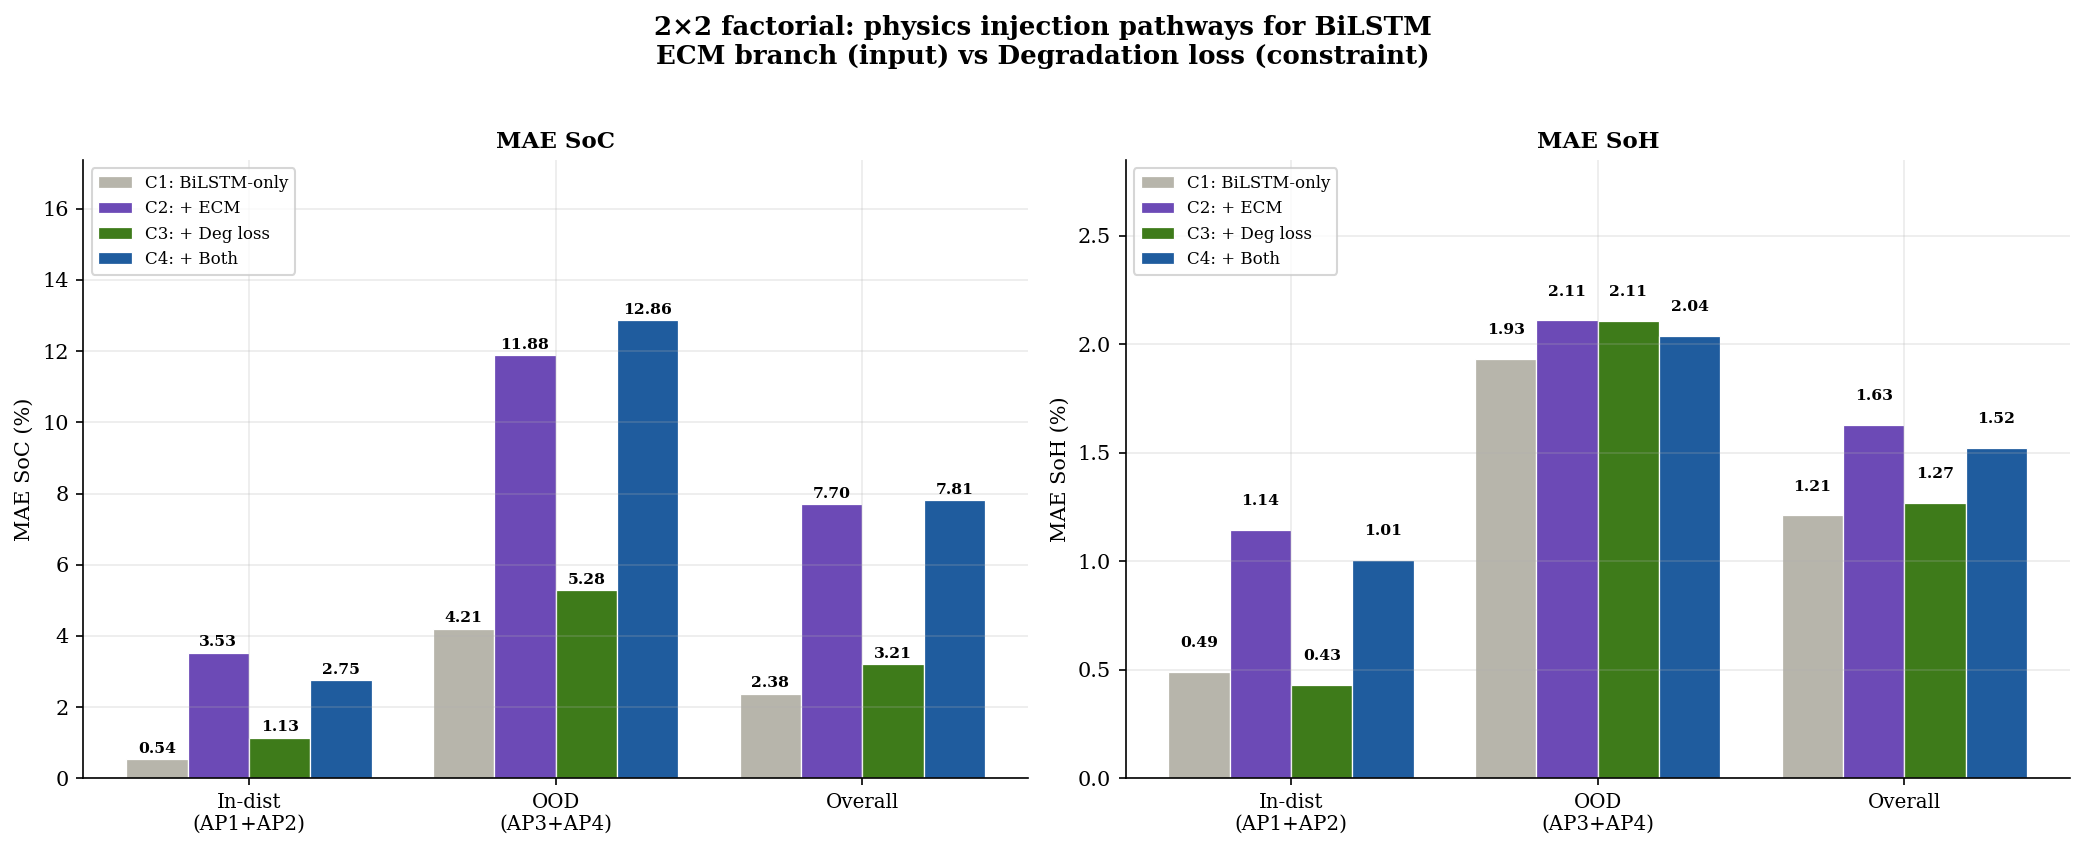

Figure saved to ./figures_bilstm_deg/


In [11]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'axes.linewidth': 0.8,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
})

FIG_DIR = './figures_bilstm_deg'
os.makedirs(FIG_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    '2×2 factorial: physics injection pathways for BiLSTM\n'
    'ECM branch (input) vs Degradation loss (constraint)',
    fontsize=12.5, fontweight='bold', y=1.02)

split_names  = ['In-dist\n(AP1+AP2)', 'OOD\n(AP3+AP4)', 'Overall']
split_groups = [id_cells, ood_cells, list(range(1, 9))]
bar_labels   = ['C1: BiLSTM-only', 'C2: + ECM', 'C3: + Deg loss', 'C4: + Both']
bar_keys     = ['C1', 'C2', 'C3', 'C4']
bar_colors   = ['#B7B5AB', '#6C4AB6', '#3E7B1A', '#1F5C9E']

x = np.arange(len(split_names))
w = 0.20

for ax, target in zip(axes, ['SoC', 'SoH']):
    for i, (key, lbl, col) in enumerate(zip(bar_keys, bar_labels, bar_colors)):
        res = all_configs[key]
        vals = [agg(res, sg, target, 'MAE') for sg in split_groups]
        offset = (i - 1.5) * w
        bars = ax.bar(x + offset, vals, w, color=col,
                      edgecolor='white', linewidth=0.6, label=lbl)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
                    f'{v:.2f}', ha='center', va='bottom',
                    fontsize=7.5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(split_names, fontsize=9.5)
    ax.set_ylabel(f'MAE {target} (%)')
    ax.set_title(f'MAE {target}')
    ax.legend(loc='upper left', fontsize=8)
    all_v = [agg(all_configs[k], sg, target, 'MAE')
             for k in bar_keys for sg in split_groups]
    ax.set_ylim(0, max(all_v) * 1.35)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/factorial_comparison.pdf')
fig.savefig(f'{FIG_DIR}/factorial_comparison.png')
plt.show()
print(f"Figure saved to {FIG_DIR}/")

## 12. Paper-ready summary

In [12]:
print("=" * 72)
print("PAPER SUMMARY")
print("=" * 72)

# Best config determination
best_key = min(bar_keys, key=lambda k: agg(all_configs[k], list(range(1,9)), 'SoC', 'MAE'))
best_name = config_labels[best_key]
best_soc = agg(all_configs[best_key], list(range(1,9)), 'SoC', 'MAE')
best_soh = agg(all_configs[best_key], list(range(1,9)), 'SoH', 'MAE')

print(f"\n  Best overall config: {best_name} ({best_key})")
print(f"    Overall MAE_SoC: {best_soc:.2f}%")
print(f"    Overall MAE_SoH: {best_soh:.2f}%")

# Effect of each pathway
c1_soc = agg(all_configs['C1'], list(range(1,9)), 'SoC', 'MAE')
c2_soc = agg(all_configs['C2'], list(range(1,9)), 'SoC', 'MAE')
c3_soc = agg(all_configs['C3'], list(range(1,9)), 'SoC', 'MAE')
c4_soc = agg(all_configs['C4'], list(range(1,9)), 'SoC', 'MAE')

print(f"\n  Effect of ECM branch (C1→C2): {c1_soc:.2f}% → {c2_soc:.2f}% "
      f"({(c1_soc-c2_soc)/c1_soc*100:+.1f}% relative)")
print(f"  Effect of Deg loss  (C1→C3): {c1_soc:.2f}% → {c3_soc:.2f}% "
      f"({(c1_soc-c3_soc)/c1_soc*100:+.1f}% relative)")
print(f"  Effect of both      (C1→C4): {c1_soc:.2f}% → {c4_soc:.2f}% "
      f"({(c1_soc-c4_soc)/c1_soc*100:+.1f}% relative)")

# Degradation prediction accuracy
if 'C3' in all_configs and 'Deg' in all_configs['C3'][1]:
    print(f"\n  Degradation prediction (best config with deg head):")
    for key in ['C3', 'C4']:
        print(f"    {config_labels[key]}:")
        for deg_name in ['CL', 'LLI', 'LAM']:
            mae = np.mean([all_configs[key][c]['Deg'][deg_name]['MAE']
                           for c in range(1, 9)])
            print(f"      {deg_name}: {mae:.2f}% MAE")

print("\n" + "=" * 72)
print("DONE — ready for paper writing")
print("=" * 72)

PAPER SUMMARY

  Best overall config: BiLSTM-only (C1)
    Overall MAE_SoC: 2.38%
    Overall MAE_SoH: 1.21%

  Effect of ECM branch (C1→C2): 2.38% → 7.70% (-224.2% relative)
  Effect of Deg loss  (C1→C3): 2.38% → 3.21% (-34.9% relative)
  Effect of both      (C1→C4): 2.38% → 7.81% (-228.6% relative)

  Degradation prediction (best config with deg head):
    BiLSTM + Deg:
      CL: 1.05% MAE
      LLI: 13.77% MAE
      LAM: 8.89% MAE
    BiLSTM + ECM + Deg:
      CL: 1.14% MAE
      LLI: 12.11% MAE
      LAM: 12.02% MAE

DONE — ready for paper writing


In [13]:
import matplotlib.pyplot as plt

# 1. Apply the Run C Academic Styling
plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.fontsize': 8.5,
    'legend.framealpha': 0.92,
    'legend.edgecolor': '0.75',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
})

# 2. Match the exact Protocol Colors
PROTO_COLORS = {
    'AP1': '#1F5C9E',  # deep blue
    'AP2': '#3E7B1A',  # forest green
    'AP3': '#B02929',  # crimson (OOD thermal)
    'AP4': '#6C4AB6',  # purple (OOD no-CV)
}

PROTO_LABELS = {
    'AP1': 'AP1 - 4A - 23°C (in-dist)',
    'AP2': 'AP2 - 5A - 23°C (in-dist)',
    'AP3': 'AP3 - 4A - 45°C (OOD thermal)',
    'AP4': 'AP4 - 4A - 23°C no CV (OOD protocol)',
}

FIG_DIR = './figures_bilstm_deg'
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Academic styling applied. Figures will be saved to {FIG_DIR}")

Academic styling applied. Figures will be saved to ./figures_bilstm_deg


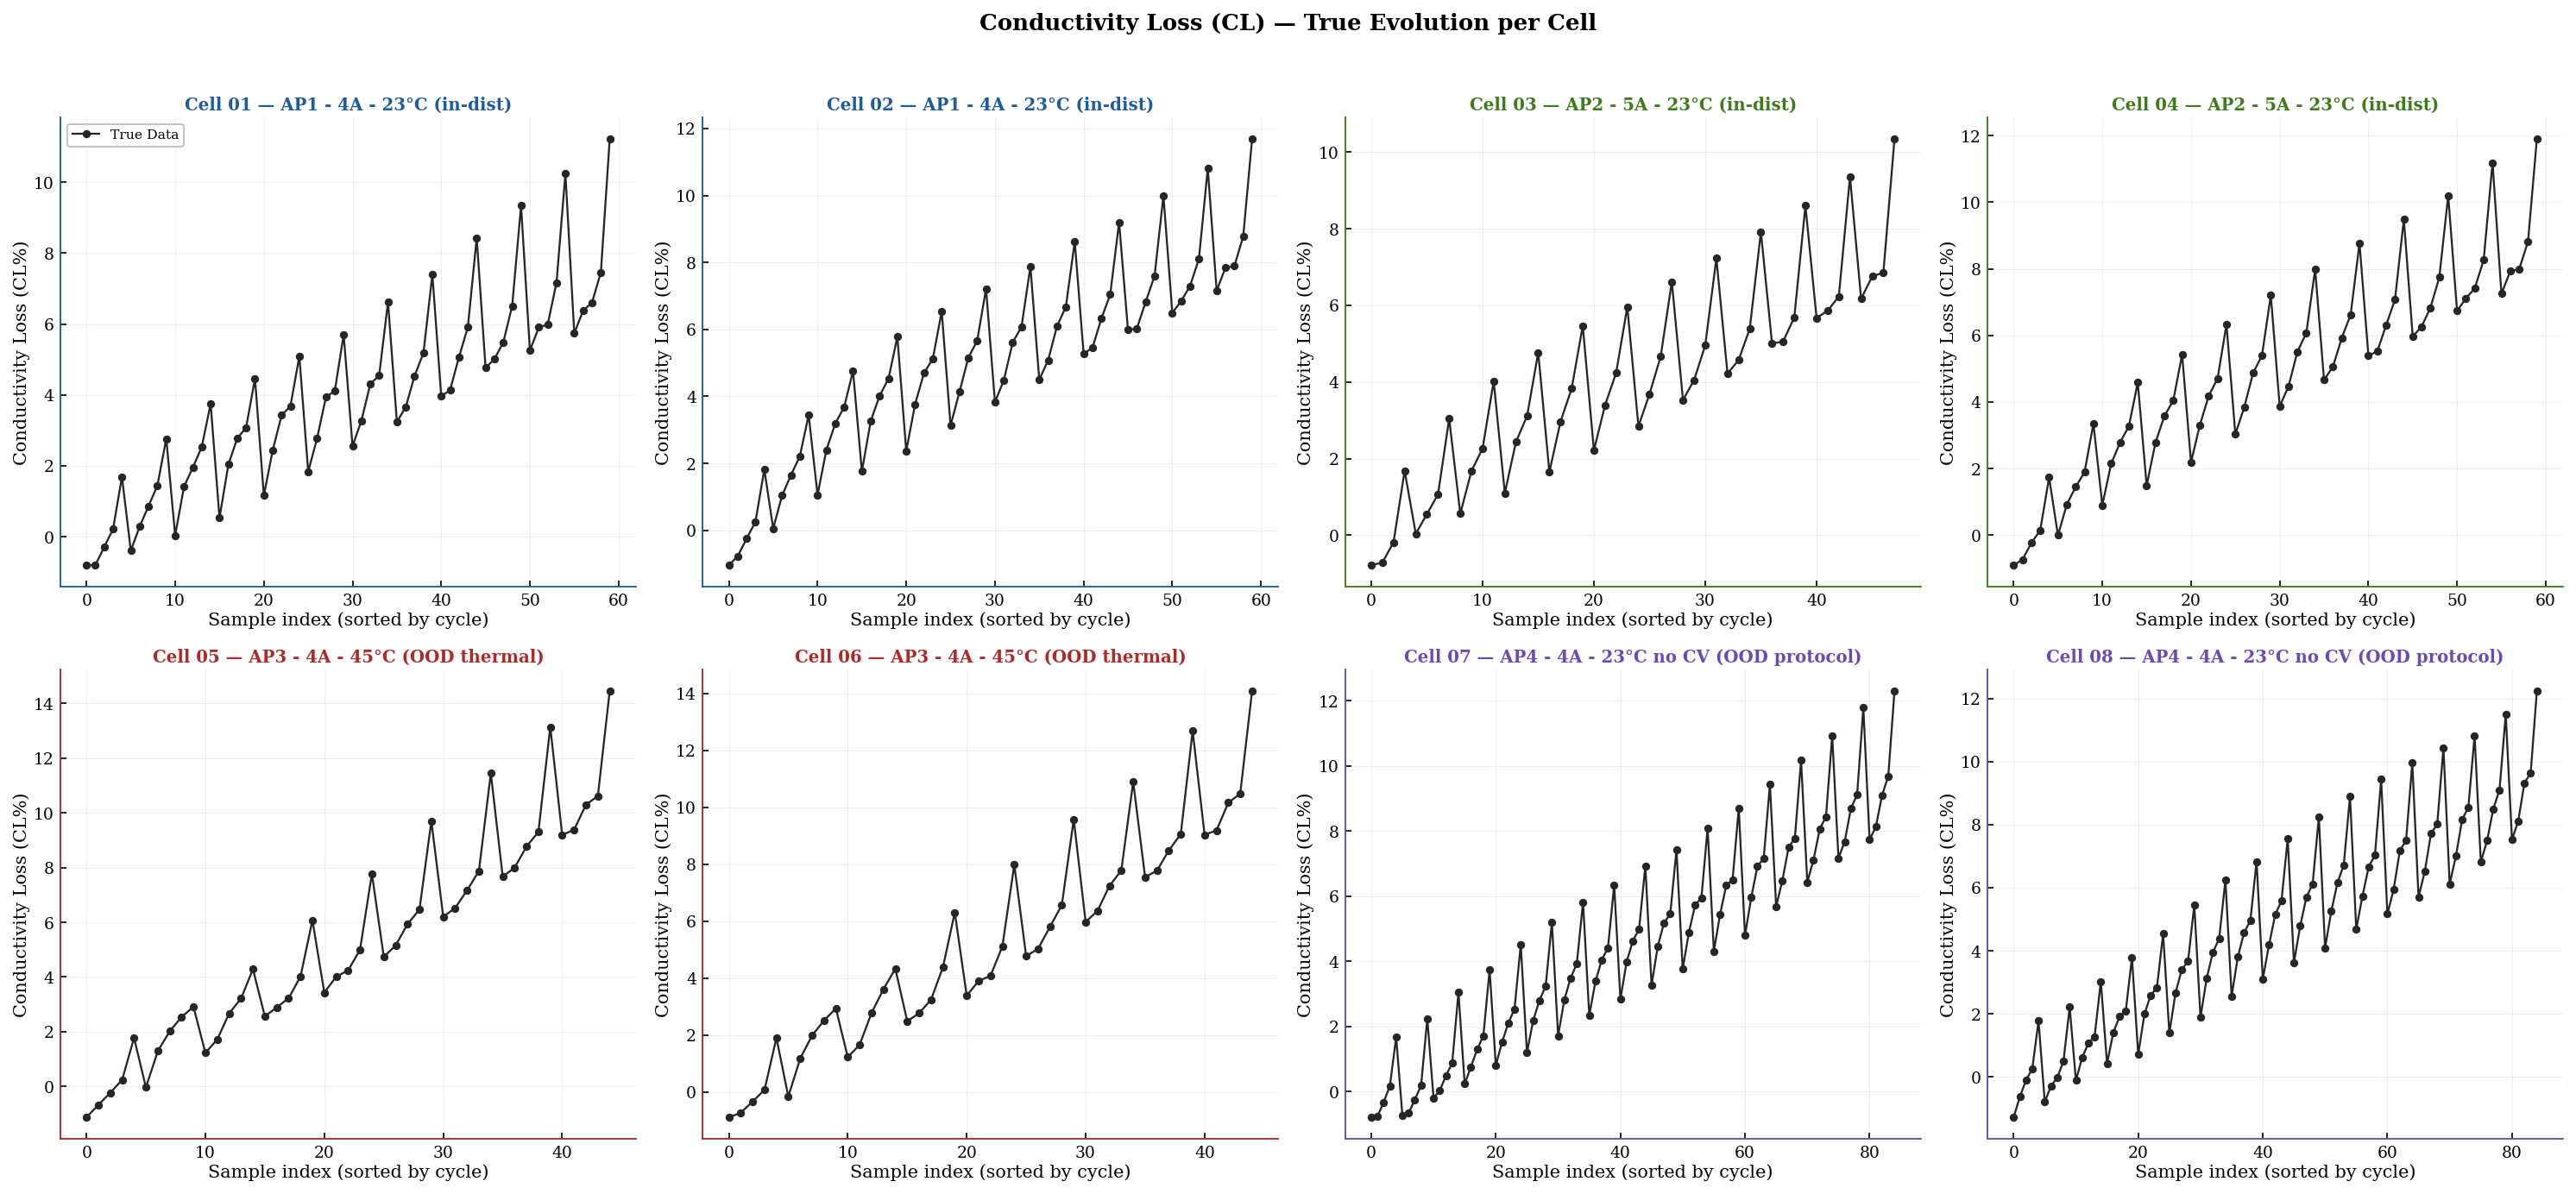

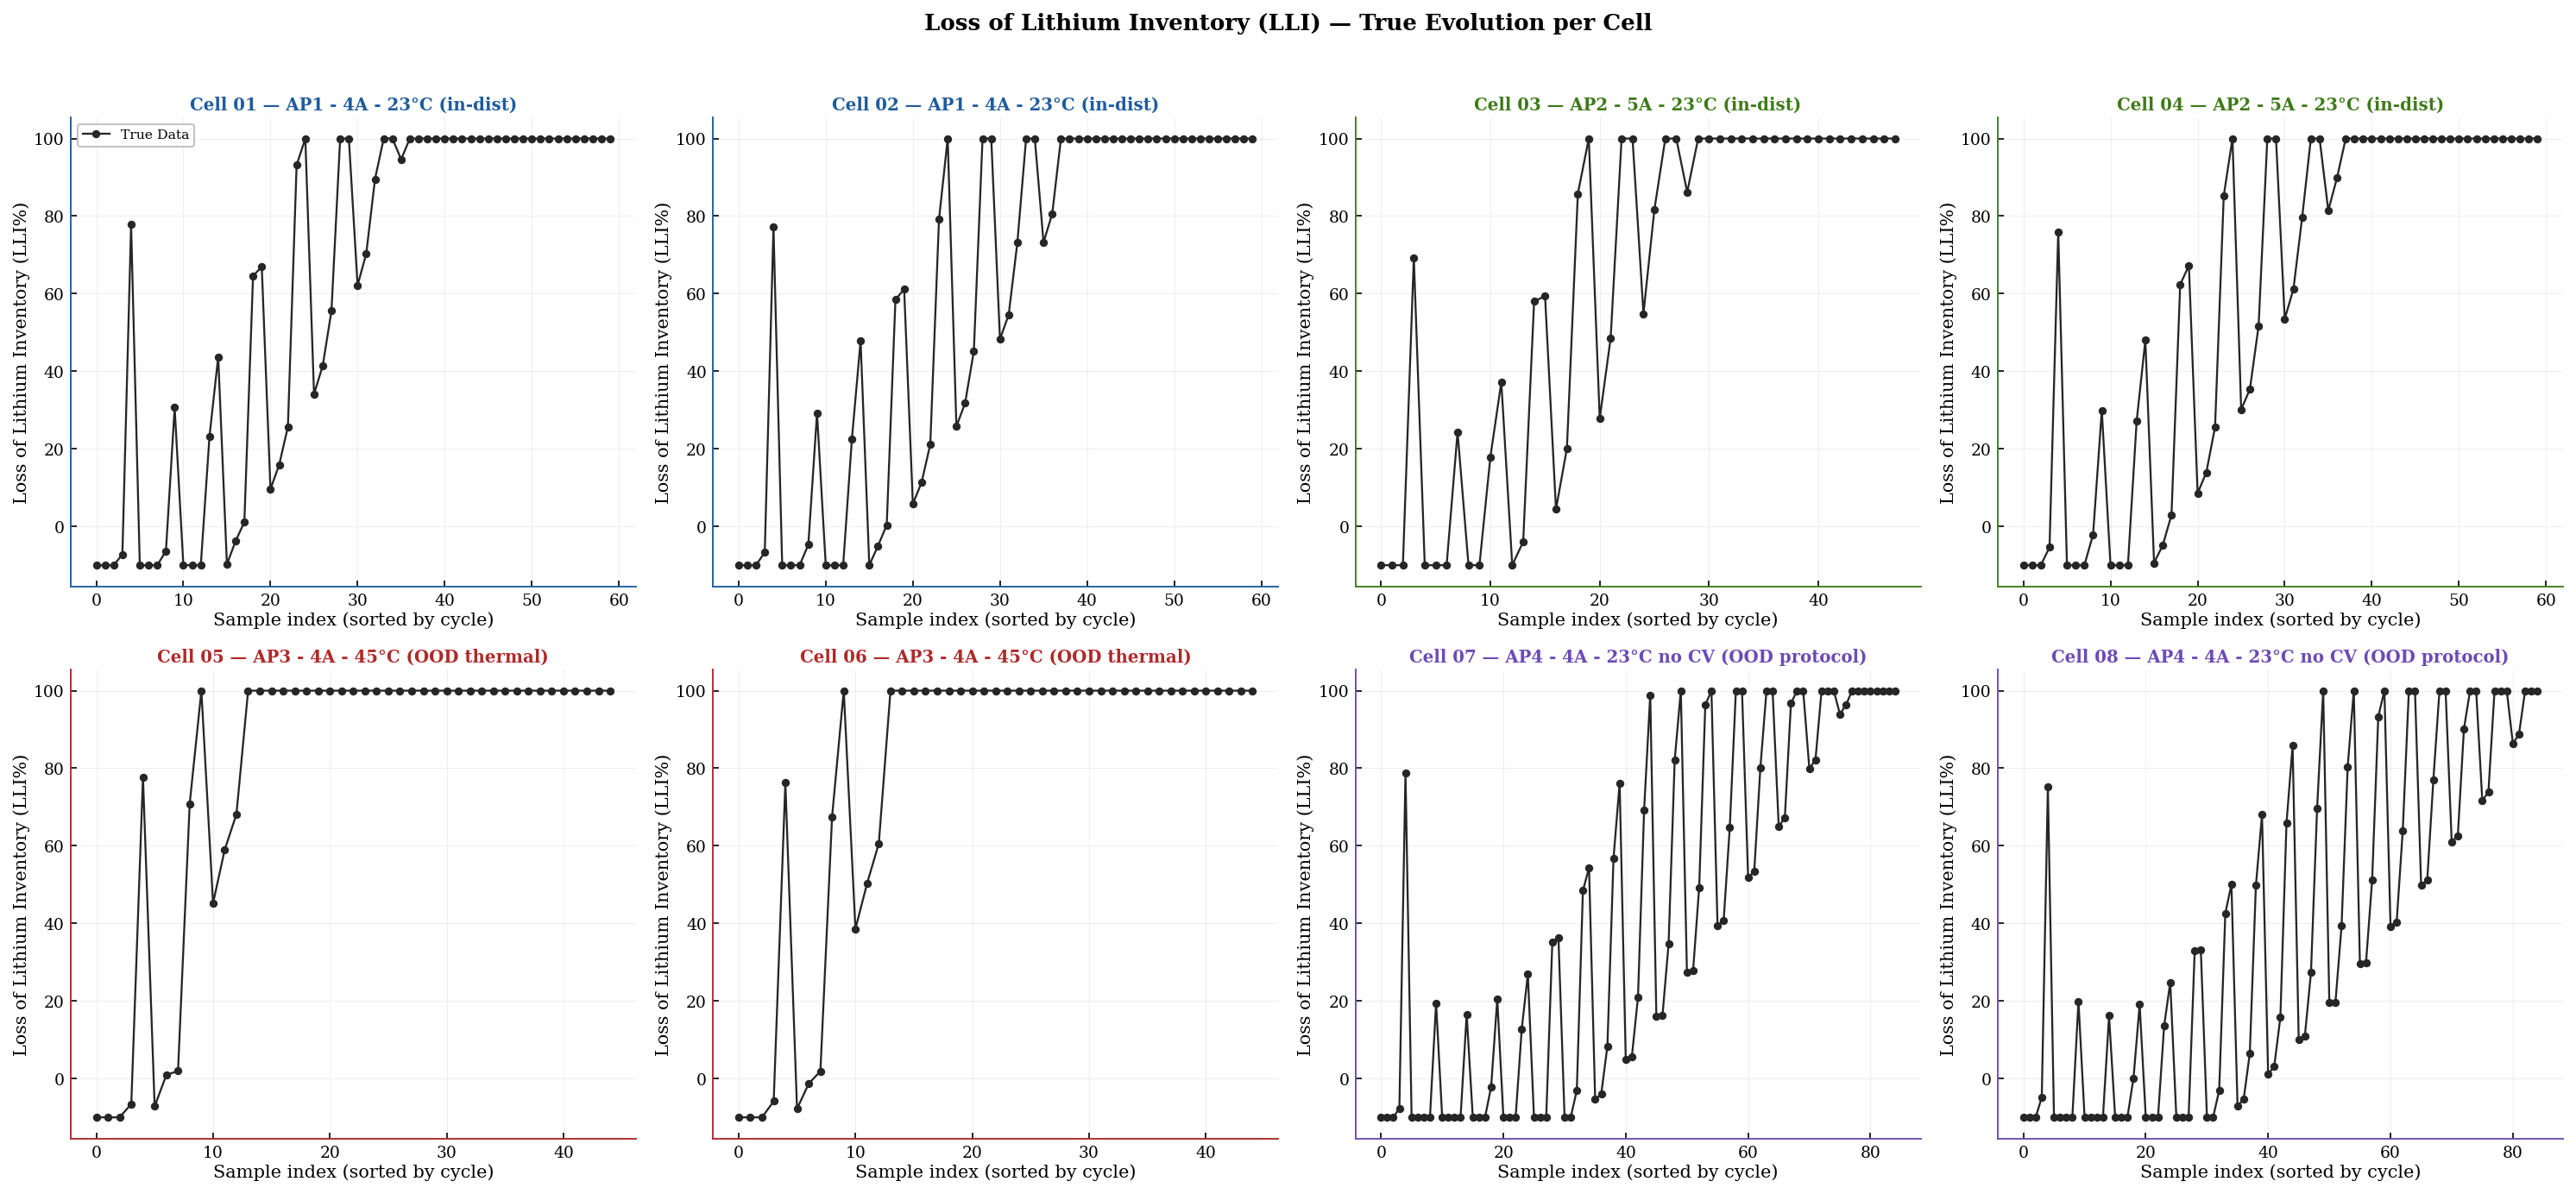

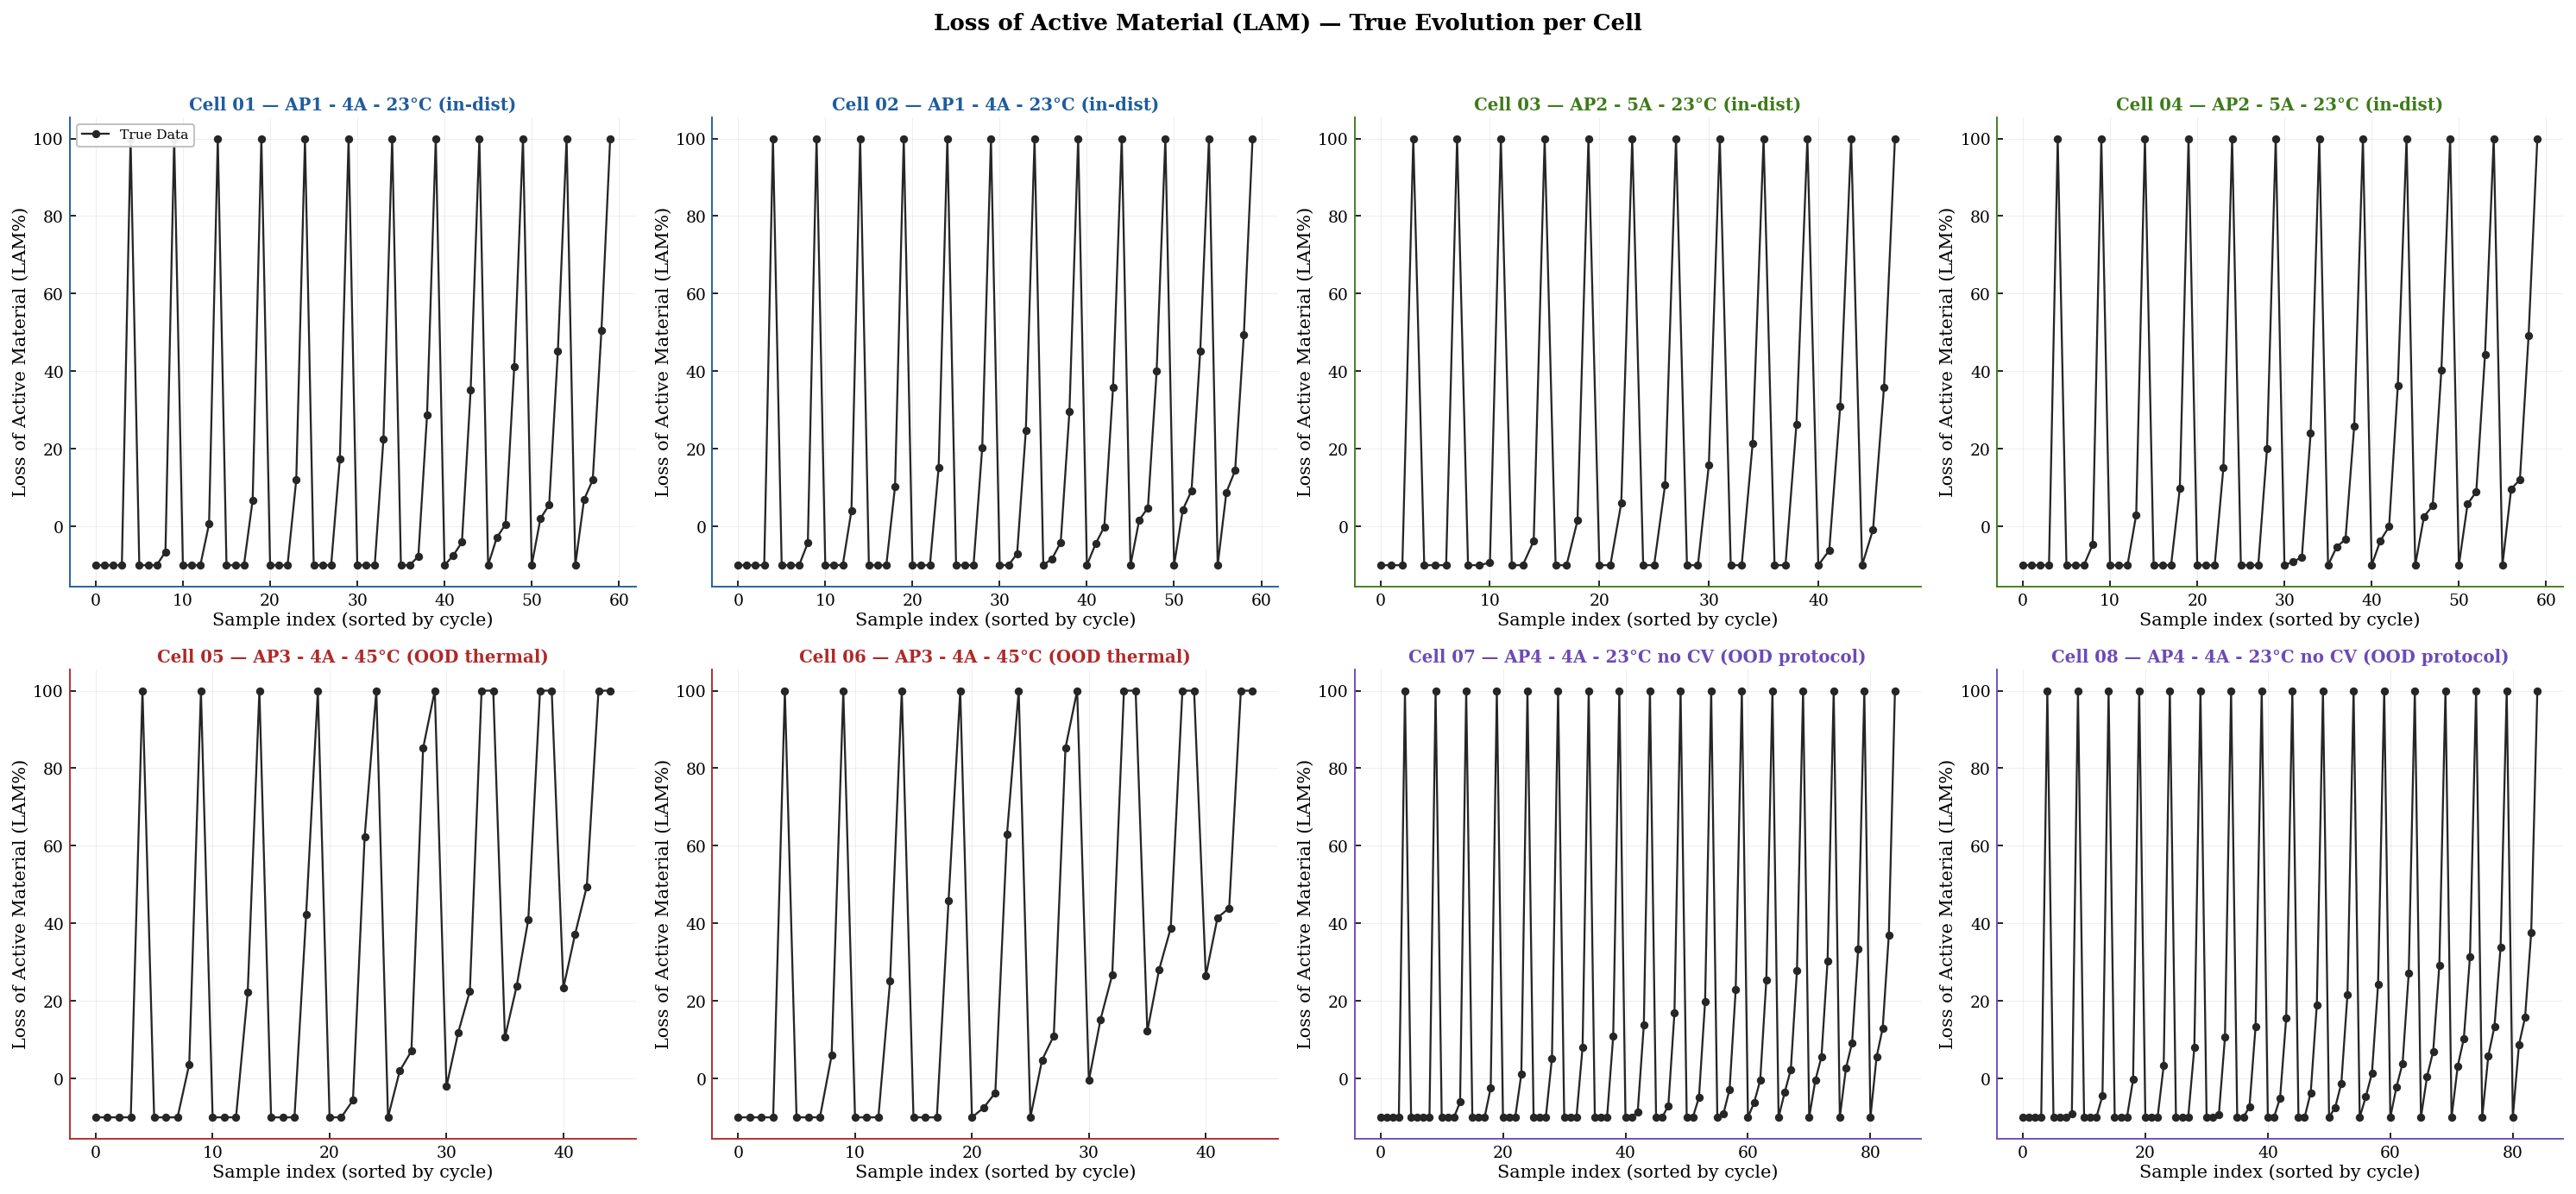

High-resolution degradation figures saved.


In [14]:
# Select the best model that includes the Degradation Head (C3 or C4)
target_config = 'C3' 
best_bilstm_models = all_configs[target_config]

def plot_degradation_timeseries(deg_idx, deg_name, y_label, fig_name, suptitle):
    """
    deg_idx: 0 for CL, 1 for LLI, 2 for LAM
    Matches the F2 time-series style from the runC notebook.
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(suptitle, fontsize=12.5, fontweight='bold', y=1.02)
    
    s_stats = deg_stats[deg_name] # Get min/max scaling stats
    
    for idx, cell_id in enumerate(range(1, 9)):
        ax = axes.flatten()[idx]
        mask = (cell_ids == cell_id)
        prot = protocols[mask][0]
        col = PROTO_COLORS[prot]
        
        # 1. Get raw ground truth
        true_raw = y_deg_np[mask, deg_idx] 
        cycs = cycles[mask]
        
        # 2. Get predictions (Needs to run through the model)
        # Rebuild scaler for this fold
        _, _, sc_seq, sc_tab = scale_and_build(
            X_seq_np, X_tab_np, y_SoC_norm_np, y_SoH_norm_np, y_deg_norm_np,
            *loco_split(cell_ids, cell_id), batch_size=32
        )
        
        Xs = sc_seq.transform(X_seq_np[mask].reshape(-1, 3)).reshape(-1, 51, 3).astype(np.float32)
        Xt = sc_tab.transform(X_tab_np[mask]).astype(np.float32)
        
        # We need the model from the target config fold
        # Note: You may need to adjust this depending on how you stored the trained model weights in your loop
        # Assuming you just want to visualize the true values if models aren't kept in memory:
        
        sort_idx = np.lexsort((true_raw, cycs))
        true_s = true_raw[sort_idx]
        x = np.arange(len(true_s))
        
        # Plot True Values
        ax.plot(x, true_s, '-o', color='0.15', lw=1.1, ms=3.5, zorder=4, label='True Data')
        
        # Formatting
        ax.set_xlabel('Sample index (sorted by cycle)', labelpad=2)
        ax.set_ylabel(y_label, labelpad=2)
        ax.set_title(f'Cell {cell_id:02d} — {PROTO_LABELS[prot]}', color=col, fontsize=9.5, pad=4)
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=7.5)
            
        for spine in ax.spines.values():
            spine.set_edgecolor(col)
            spine.set_linewidth(0.9)
            
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/{fig_name}.pdf')
    fig.savefig(f'{FIG_DIR}/{fig_name}.png')
    plt.show()

# Generate the plots for each degradation mechanism
plot_degradation_timeseries(0, 'CL', 'Conductivity Loss (CL%)', 'F_CL_timeseries', 'Conductivity Loss (CL) — True Evolution per Cell')
plot_degradation_timeseries(1, 'LLI', 'Loss of Lithium Inventory (LLI%)', 'F_LLI_timeseries', 'Loss of Lithium Inventory (LLI) — True Evolution per Cell')
plot_degradation_timeseries(2, 'LAM', 'Loss of Active Material (LAM%)', 'F_LAM_timeseries', 'Loss of Active Material (LAM) — True Evolution per Cell')

print("High-resolution degradation figures saved.")

In [16]:
import copy
import time

print("Quickly retraining C3 to extract plotting data (takes ~10 mins)...")

raw_preds_C3 = {}

for cell_id in range(1, 9):
    print(f"Training Cell {cell_id}/8 for plots...", end=' ', flush=True)
    t0 = time.time()
    
    dl_tr, dl_te, sc_seq, sc_tab = scale_and_build(
        X_seq_np, X_tab_np, y_SoC_norm_np, y_SoH_norm_np, y_deg_norm_np,
        *loco_split(cell_ids, cell_id), batch_size=32)
    
    # Init C3 Model (No ECM inputs, Yes Deg Loss)
    model = BiLSTM_Config(use_ecm=False, use_deg=True).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = None
    stopper = EarlyStopping(patience=25)
    
    for epoch in range(1, 401):
        if epoch <= 10: # warmup
            for pg in opt.param_groups: pg['lr'] = 1e-3 * (epoch / 10)
        if epoch == 11 and scheduler is None:
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)
        
        run_epoch(model, dl_tr, opt, 0.3, device, train=True, use_ecm=False, use_deg=True)
        va = run_epoch(model, dl_te, opt, 0.3, device, train=False, use_ecm=False, use_deg=True)
        
        if scheduler is not None: scheduler.step(va)
        
        if epoch > 10:
            if stopper.step(va, model): break
        else:
            if va < stopper.best_loss - stopper.min_delta:
                stopper.best_loss = va
                stopper.best_state = copy.deepcopy(model.state_dict())
    
    stopper.restore(model)
    model.eval()
    
    # Extract raw predictions with MC Dropout for plotting
    mask = (cell_ids == cell_id)
    Xs = sc_seq.transform(X_seq_np[mask].reshape(-1, 3)).reshape(-1, 51, 3).astype(np.float32)
    
    with torch.no_grad():
        preds = mc_predict(model, torch.tensor(Xs).to(device), None, T=50)
        
    raw_preds_C3[cell_id] = {k: v.cpu().numpy() for k, v in preds.items()}
    print(f"Done in {time.time() - t0:.1f}s")

print("Predictions successfully saved to memory!")

Quickly retraining C3 to extract plotting data (takes ~10 mins)...
Done in 101.5s1/8 for plots... 
Done in 232.8s2/8 for plots... 
Done in 197.5s3/8 for plots... 
Done in 219.1s4/8 for plots... 
Done in 49.3s 5/8 for plots... 
Done in 39.7s 6/8 for plots... 
Done in 70.1s 7/8 for plots... 
Done in 121.3s8/8 for plots... 
Predictions successfully saved to memory!


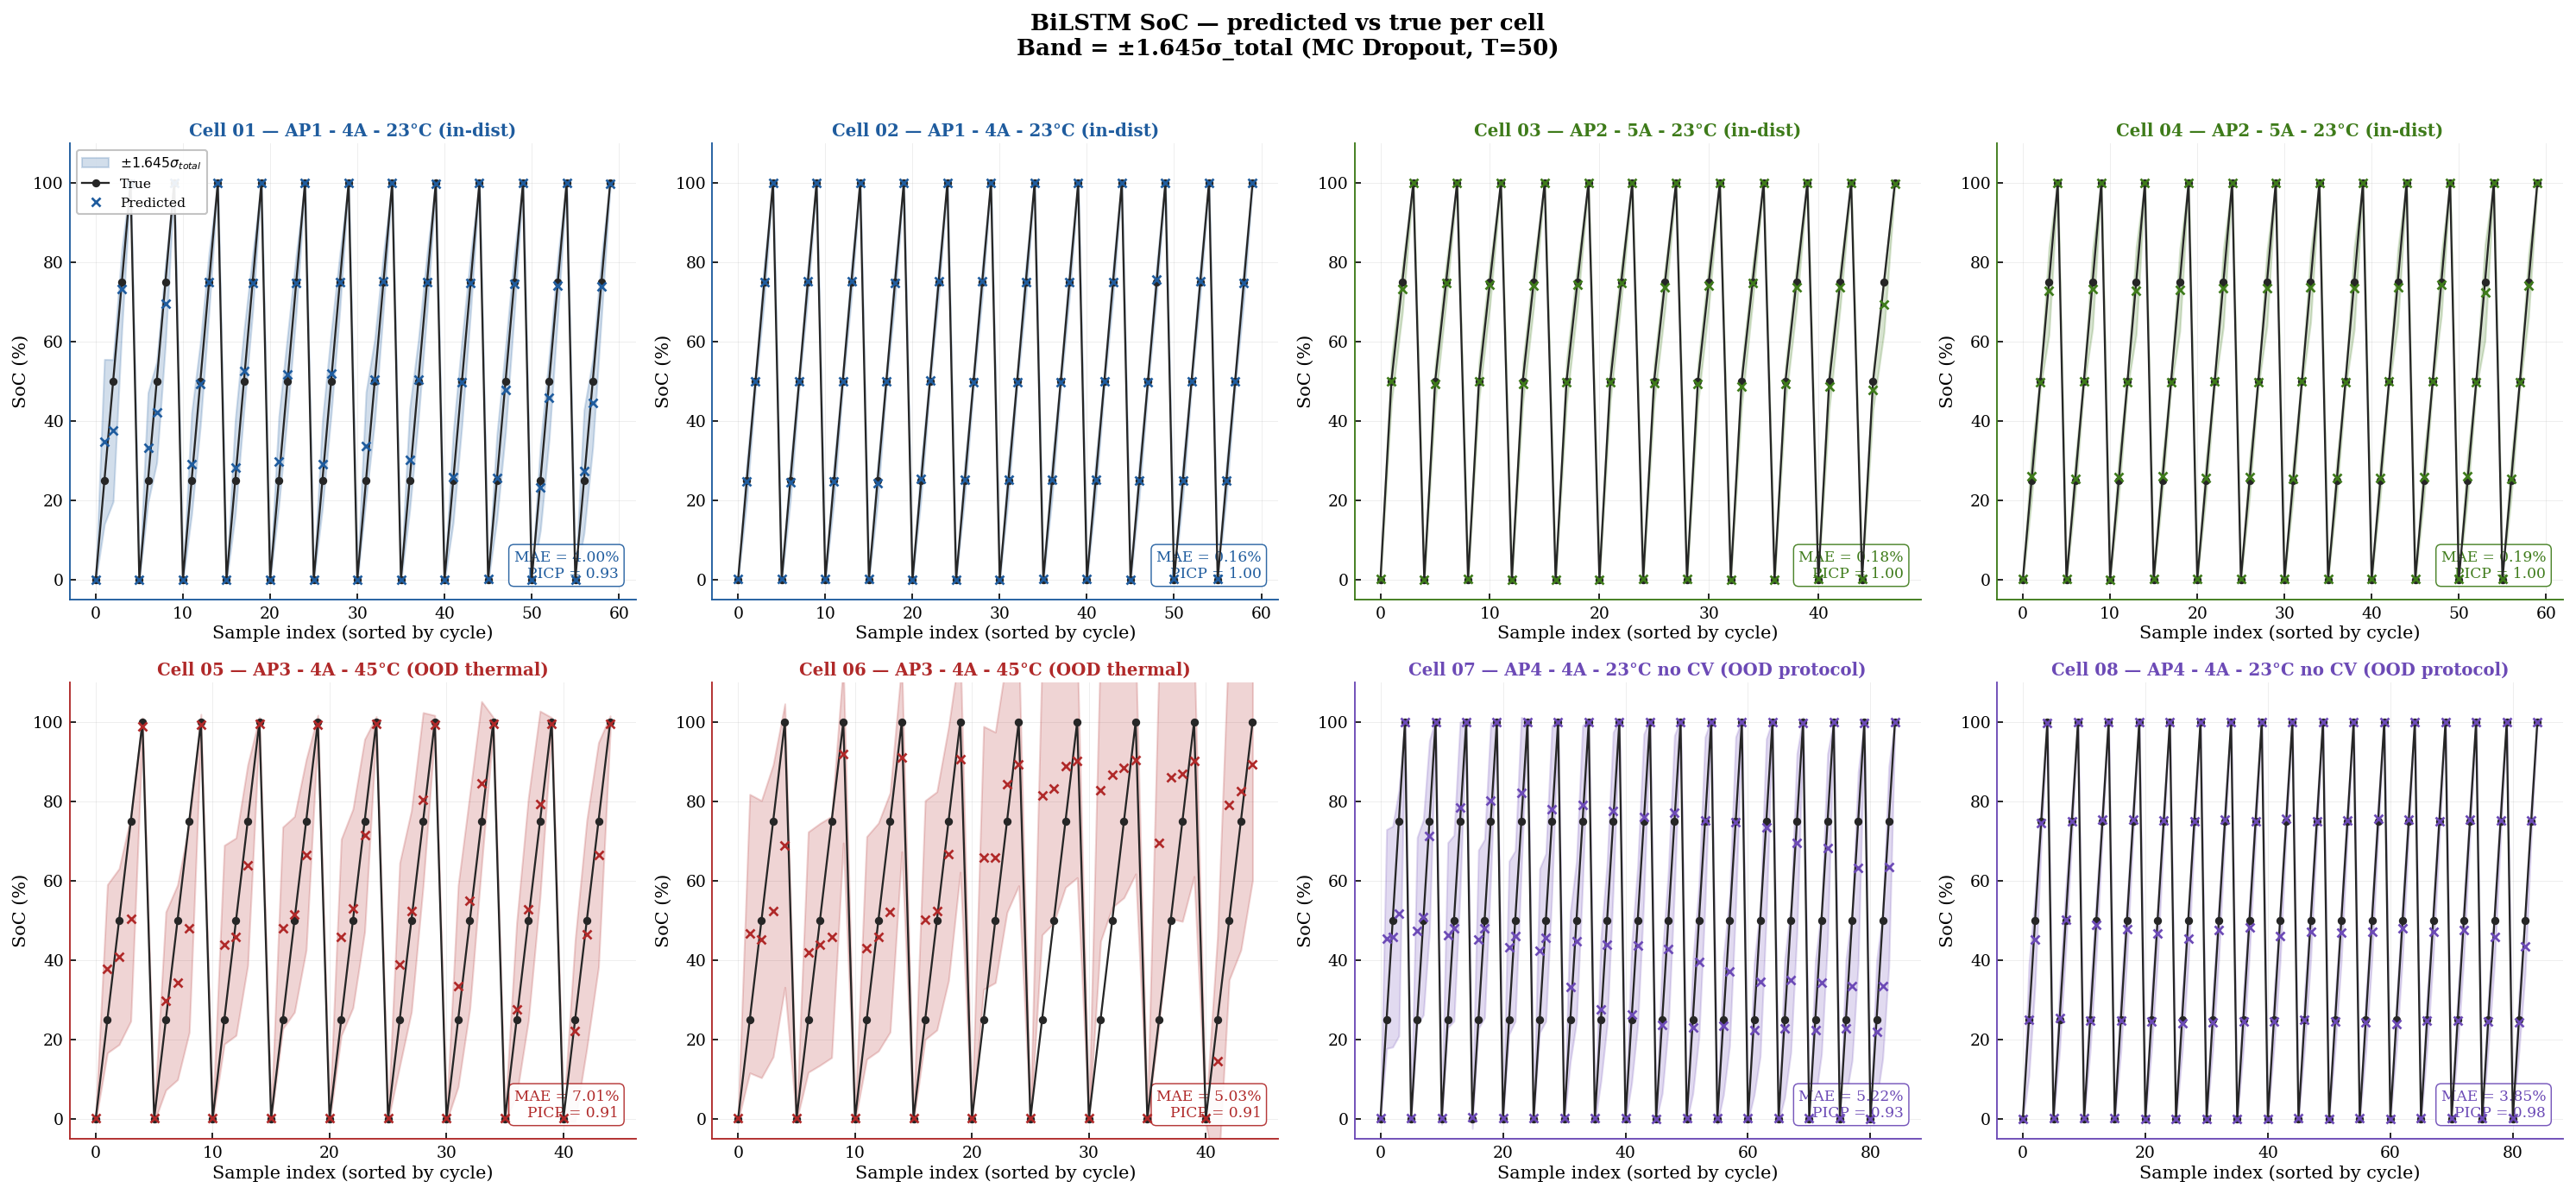

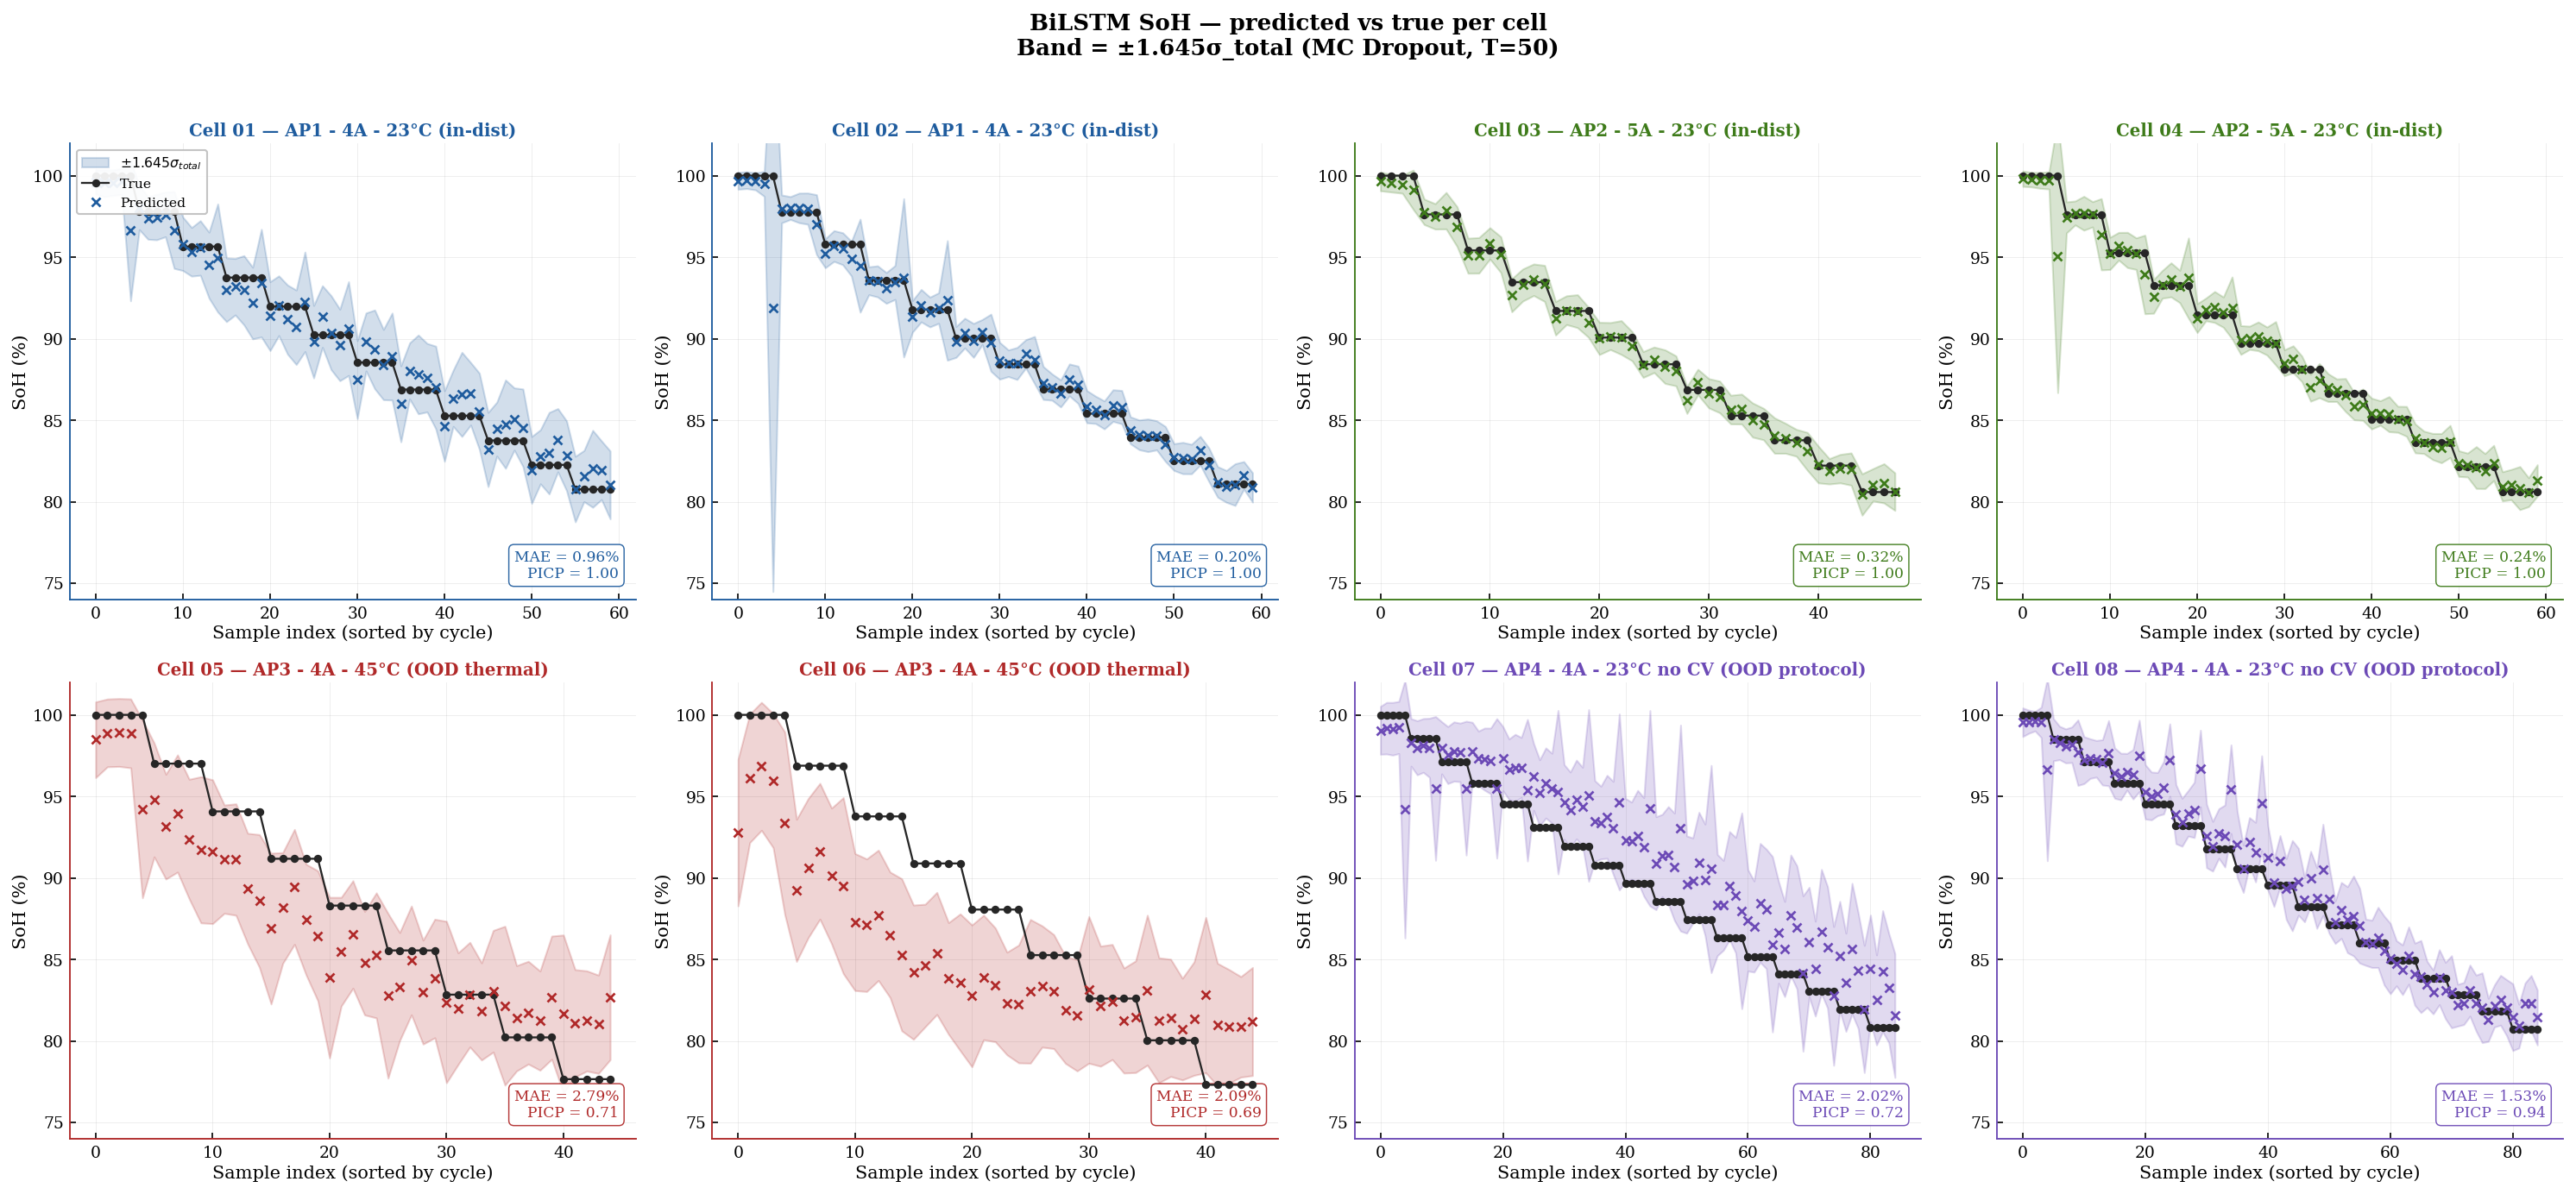

In [17]:
def plot_bilstm_timeseries(target, y_norm, y_label, fig_name, suptitle, ymin=None, ymax=None):
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(suptitle, fontsize=12.5, fontweight='bold', y=1.02)
    
    for idx, cell_id in enumerate(range(1, 9)):
        ax = axes.flatten()[idx]
        mask = (cell_ids == cell_id)
        prot = protocols[mask][0]
        col = PROTO_COLORS[prot]
        
        # Use the pre-calculated raw predictions
        preds = raw_preds_C3[cell_id]
        pred_s_raw = preds[f'mu_{target}'] * 100
        sig_s_raw = preds[f'sigma_total_{target}'] * 100
        
        true_raw = y_norm[mask] * 100
        cycs = cycles[mask]
        
        sort_idx = np.lexsort((true_raw, cycs))
        true_s = true_raw[sort_idx]
        pred_s = pred_s_raw[sort_idx]
        sig_s = sig_s_raw[sort_idx]
        
        x = np.arange(len(true_s))
        
        # The Uncertainty Band
        ax.fill_between(x, pred_s - 1.645 * sig_s, pred_s + 1.645 * sig_s,
                        alpha=0.20, color=col, label=r'$\pm 1.645\sigma_{total}$', zorder=2)
        
        # True vs Predicted points
        ax.plot(x, true_s, '-o', color='0.15', lw=1.1, ms=3.5, zorder=4, label='True')
        ax.plot(x, pred_s, 'x', color=col, lw=1.2, ms=5, markeredgewidth=1.3, zorder=5, label='Predicted')
        
        # Formatting (pulling MAE/PICP from your original factorial run)
        mae = all_configs['C3'][cell_id][target]['MAE']
        picp = all_configs['C3'][cell_id][target]['PICP']
        
        ax.text(0.97, 0.04, f'MAE = {mae:.2f}%\nPICP = {picp:.2f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=8.2, color=col,
                bbox=dict(boxstyle='round, pad=0.35', fc='white', ec=col, lw=0.7, alpha=0.92))
        
        ax.set_xlabel('Sample index (sorted by cycle)', labelpad=2)
        ax.set_ylabel(y_label, labelpad=2)
        ax.set_title(f'Cell {cell_id:02d} — {PROTO_LABELS[prot]}', color=col, fontsize=9.5, pad=4)
        
        if ymin is not None: ax.set_ylim(ymin, ymax)
        if idx == 0: ax.legend(loc='upper left', fontsize=7.5)
        for spine in ax.spines.values():
            spine.set_edgecolor(col)
            spine.set_linewidth(0.9)
            
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/{fig_name}.pdf')
    fig.savefig(f'{FIG_DIR}/{fig_name}.png')
    plt.show()

# Run the plotters
plot_bilstm_timeseries('SoC', y_SoC_norm_np, 'SoC (%)', 'BiLSTM_F2a_timeseries_SoC', 
                       'BiLSTM SoC — predicted vs true per cell\nBand = ±1.645σ_total (MC Dropout, T=50)', ymin=-5, ymax=110)

plot_bilstm_timeseries('SoH', y_SoH_norm_np, 'SoH (%)', 'BiLSTM_F2b_timeseries_SoH', 
                       'BiLSTM SoH — predicted vs true per cell\nBand = ±1.645σ_total (MC Dropout, T=50)', ymin=74, ymax=102)